## 1. Поиск и источник данных
Датасет: [Olist Brazilian E-Commerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)
- Источник: Kaggle
- Почему выбран: содержит реальные данные о заказах, товарах, клиентах, оплатах и отзывах, подходит для задачи предсказания разочарования пользователя после покупки.

## 2. Описание датасета
- Несколько связанных таблиц: заказы, клиенты, товары, отзывы, платежи и др.
- Объем: ~100k+ строк, 10+ таблиц (уточнить после загрузки)
- Целевая переменная: вероятность разочарования (по отзывам)

## 3. Загрузка и первичный анализ

In [16]:
import pandas as pd
import os

RAW_PATH = '../data/raw/'

customers = pd.read_csv(
    os.path.join(RAW_PATH, 'olist_customers_dataset.csv')
)

geolocation = pd.read_csv(
    os.path.join(RAW_PATH, 'olist_geolocation_dataset.csv')
)

order_items = pd.read_csv(
    os.path.join(RAW_PATH, 'olist_order_items_dataset.csv')
)

payments = pd.read_csv(
    os.path.join(RAW_PATH, 'olist_order_payments_dataset.csv')
)

reviews = pd.read_csv(
    os.path.join(RAW_PATH, 'olist_order_reviews_dataset.csv')
)

orders = pd.read_csv(
    os.path.join(RAW_PATH, 'olist_orders_dataset.csv'),
    parse_dates=[
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
)

products = pd.read_csv(
    os.path.join(RAW_PATH, 'olist_products_dataset.csv')
)

sellers = pd.read_csv(
    os.path.join(RAW_PATH, 'olist_sellers_dataset.csv')
)

category_translation = pd.read_csv(
    os.path.join(RAW_PATH, 'product_category_name_translation.csv')
)

In [17]:
print('Orders nulls:')
print(orders.isnull().sum())

print('\nReviews nulls:')
print(reviews.isnull().sum())

print('\nOrders duplicates:', orders.duplicated().sum())
print('Reviews duplicates:', reviews.duplicated().sum())

orders = orders.drop_duplicates()
reviews = reviews.drop_duplicates()

orders = orders.dropna(subset=['order_id'])
reviews = reviews.dropna(subset=['order_id'])

Orders nulls:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Reviews nulls:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Orders duplicates: 0
Reviews duplicates: 0


In [18]:
df = orders.merge(reviews, on='order_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
df = df.merge(payments, on='order_id', how='left')
df = df.merge(order_items, on='order_id', how='left')
df = df.merge(products, on='product_id', how='left')

print(df.shape)
df.head()

(119143, 36)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4.0,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4.0,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4.0,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4.0,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5.0,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


In [19]:
df['delivery_time_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.days

df['delivery_delay_days'] = (
    df['order_delivered_customer_date'] -
    df['order_estimated_delivery_date']
).dt.days

df['review_text_length'] = (
    df['review_comment_message']
    .fillna('')
    .apply(len)
)

df['target'] = (df['review_score'] <= 2).astype(int)

df[
    [
        'delivery_time_days',
        'delivery_delay_days',
        'review_text_length',
        'target'
    ]
].head()

,delivery_time_days,delivery_delay_days,review_text_length,target
0,8.0,-8.0,170,0
1,8.0,-8.0,170,0
2,8.0,-8.0,170,0
3,13.0,-6.0,20,0
4,9.0,-18.0,0,0


In [20]:
print(df['review_score'].value_counts().sort_index())

print(df['target'].value_counts())

review_score
1.0    15428
2.0     4162
3.0     9894
4.0    22319
5.0    66343
Name: count, dtype: int64
target
0    99553
1    19590
Name: count, dtype: int64


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

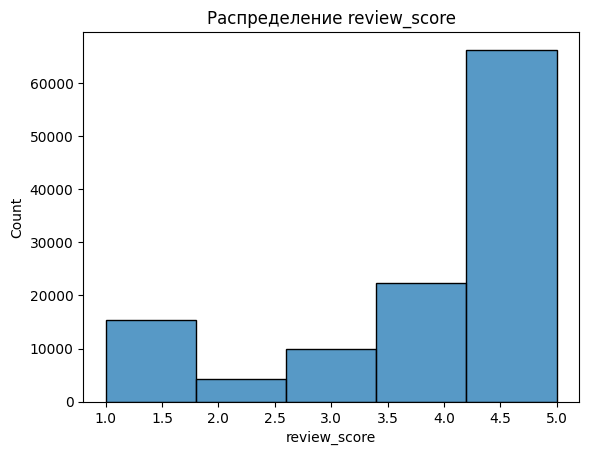

In [22]:
sns.histplot(df['review_score'], bins=5)
plt.title('Распределение review_score')
plt.show()

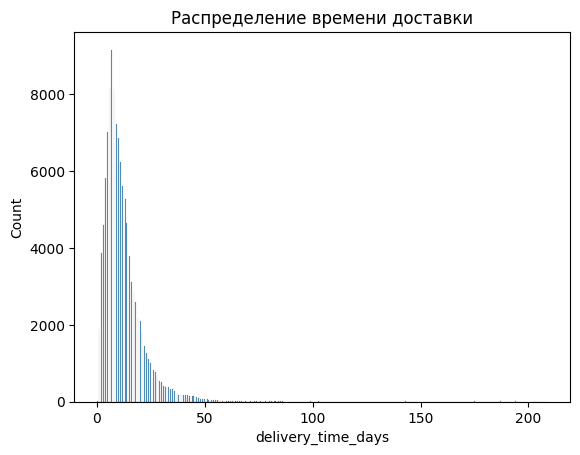

In [23]:
sns.histplot(df['delivery_time_days'].dropna())
plt.title('Распределение времени доставки')
plt.show()

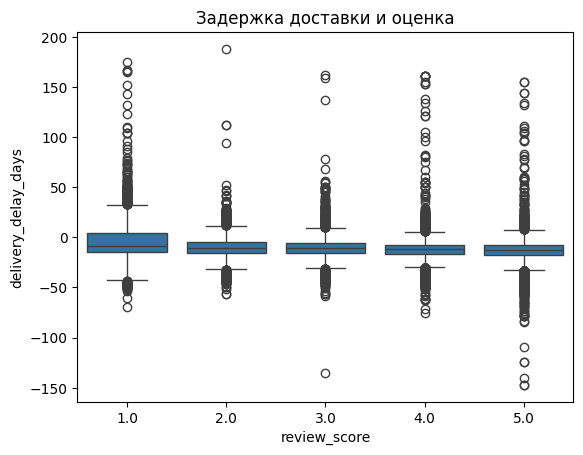

In [24]:
sns.boxplot(
    x='review_score',
    y='delivery_delay_days',
    data=df
)
plt.title('Задержка доставки и оценка')
plt.show()

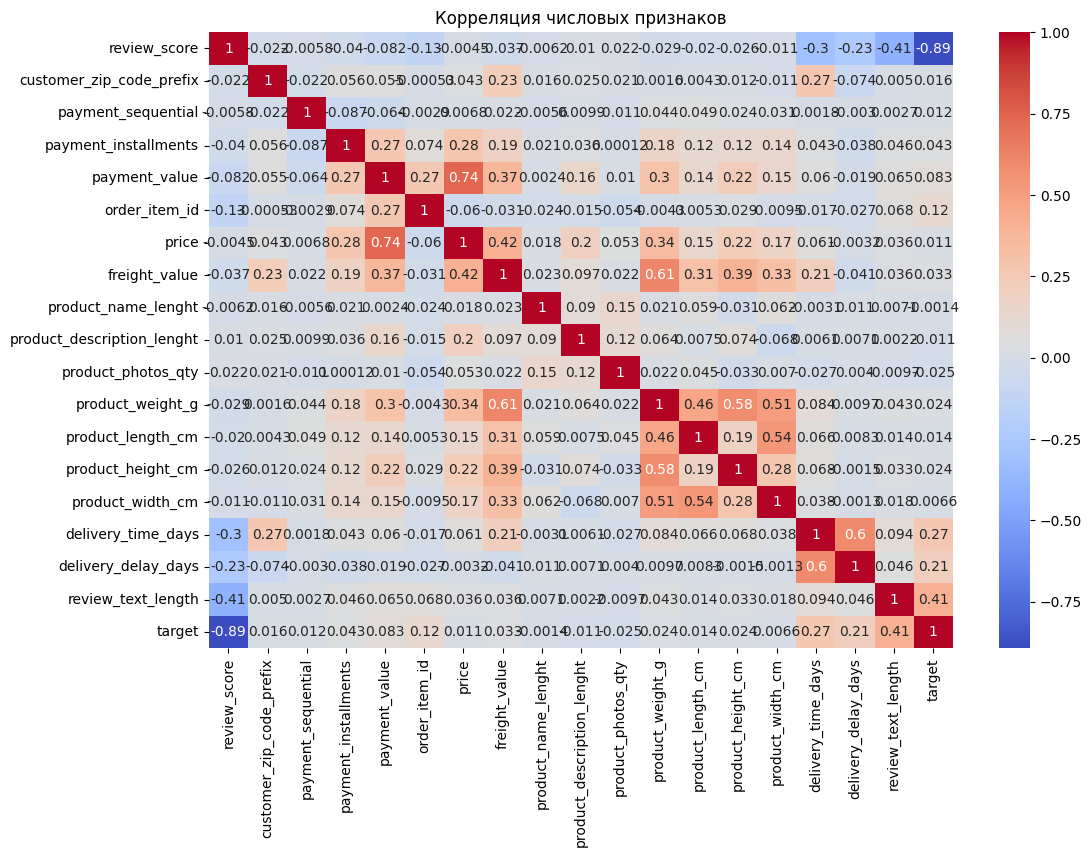

In [25]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(12, 8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Корреляция числовых признаков')
plt.show()

In [33]:
import os

# создаём папку если её нет
os.makedirs('../data/processed', exist_ok=True)

# сохраняем датасет
df.to_csv('../data/processed/df.csv', index=False)